In [1]:
from sklearn.datasets import fetch_openml
X, y = fetch_openml('mnist_784', version=1, return_X_y=True)

In [26]:
X.iloc[0]
X.sample(3)

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
57953,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
66849,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
28077,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [25]:
y[0]

'5'

<class 'pandas.core.frame.DataFrame'>


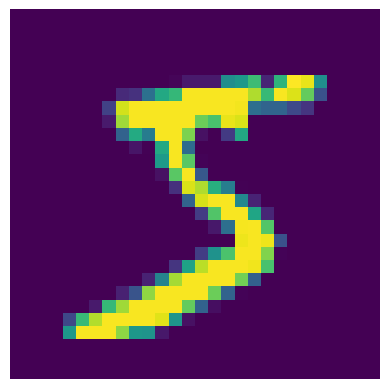

In [2]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
print(type(X))


img1 = np.array(X.iloc[0]).reshape(28,28)
plt.imshow(img1)
plt.axis("off")
plt.show()

In [3]:
from sklearn.model_selection import train_test_split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state= 42, test_size=0.2)

In [5]:
from sklearn.linear_model import LogisticRegression

In [6]:
log_reg = LogisticRegression(multi_class= 'multinomial', penalty='l2', C=1.0, solver='sag', verbose = True, max_iter= 100)

In [7]:
log_reg.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


max_iter reached after 123 seconds


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:  2.1min finished


LogisticRegression(multi_class='multinomial', solver='sag', verbose=True)

In [11]:
y_train.shape

(56000,)

In [12]:
y_pred = log_reg.predict(X_test)

In [15]:
from sklearn.metrics import accuracy_score, confusion_matrix

accuracy_score(y_test, y_pred)

0.9185

In [17]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[1289,    1,    6,    1,    4,    9,   18,    5,    9,    1],
       [   0, 1554,    6,    9,    3,    7,    0,    3,   15,    3],
       [   5,   19, 1229,   23,   13,   10,   21,   17,   33,   10],
       [   5,    7,   34, 1290,    1,   37,    8,   13,   21,   17],
       [   6,    3,    6,    4, 1191,    5,   13,    7,   10,   50],
       [  11,    7,    7,   51,   13, 1099,   22,    2,   47,   14],
       [   6,    4,   21,    1,   15,   17, 1327,    2,    3,    0],
       [   5,    4,   25,    5,   12,    4,    0, 1409,    3,   36],
       [  12,   22,   17,   43,    6,   39,   10,    8, 1185,   15],
       [   8,    7,    5,   13,   37,    6,    0,   44,   14, 1286]])

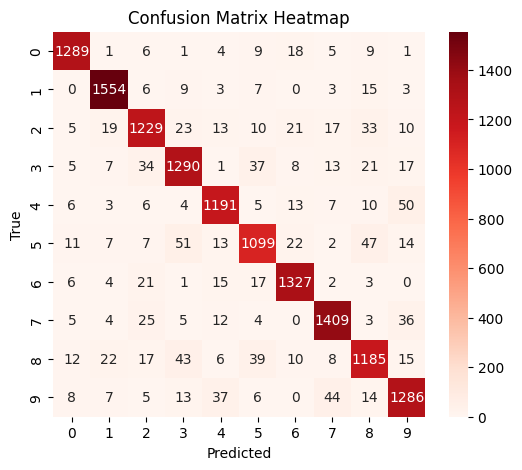

In [22]:
import seaborn as sns
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', cbar=True,
            xticklabels=[i for i in range(10)], yticklabels=[i for i in range(10)])

plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix Heatmap')
plt.show()

In [ ]:
""